In [53]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime

mpl.rcParams['figure.figsize'] = (10,8)
mpl.rcParams['axes.grid'] = False

import warnings
warnings.filterwarnings('ignore')

In [54]:
import requests 

response = requests.get(
    "https://min-api.cryptocompare.com/data/index/histo/day",
    params={"indexName":"MVDA","limit":"2000","extraParams":"close","api_key":"80569da8a484c32416a622ff7c8e5b2437f99bef2c3a8b702df01790c87ddb97"},
    headers={"Content-type":"application/json; charset=UTF-8"}
)


In [55]:
json_response = response.json()

In [56]:
df = pd.DataFrame(json_response['Data'])

In [57]:
df

,time,close,high,low,open
0,1579996800,2260.050000,2260.41,2166.05,2178.70
1,1580083200,2331.680000,2355.81,2242.32,2260.05
2,1580169600,2439.620000,2465.15,2290.80,2331.68
3,1580256000,2419.410000,2461.68,2387.10,2439.62
4,1580342400,2492.450000,2510.33,2370.00,2419.41
...,...,...,...,...,...
1996,1752451200,23712.350000,24311.12,23484.50,23514.98
1997,1752537600,23557.640000,23745.49,22970.01,23712.35
1998,1752624000,24030.750000,24312.68,23374.65,23557.25
1999,1752710400,24473.500000,24727.12,23780.25,24030.76


In [58]:
df['time'] = pd.to_datetime(df['time'], unit='s')

In [59]:
df = df[['time', 'close']]

In [60]:
df.rename(columns={'time': 'Date', 'close':'bpi'}, inplace=True)

In [61]:
df.set_index('Date', inplace=True)

In [62]:
df

,bpi
Date,
2020-01-26,2260.050000
2020-01-27,2331.680000
2020-01-28,2439.620000
2020-01-29,2419.410000
2020-01-30,2492.450000
...,...
2025-07-14,23712.350000
2025-07-15,23557.640000
2025-07-16,24030.750000


<Axes: xlabel='Date'>

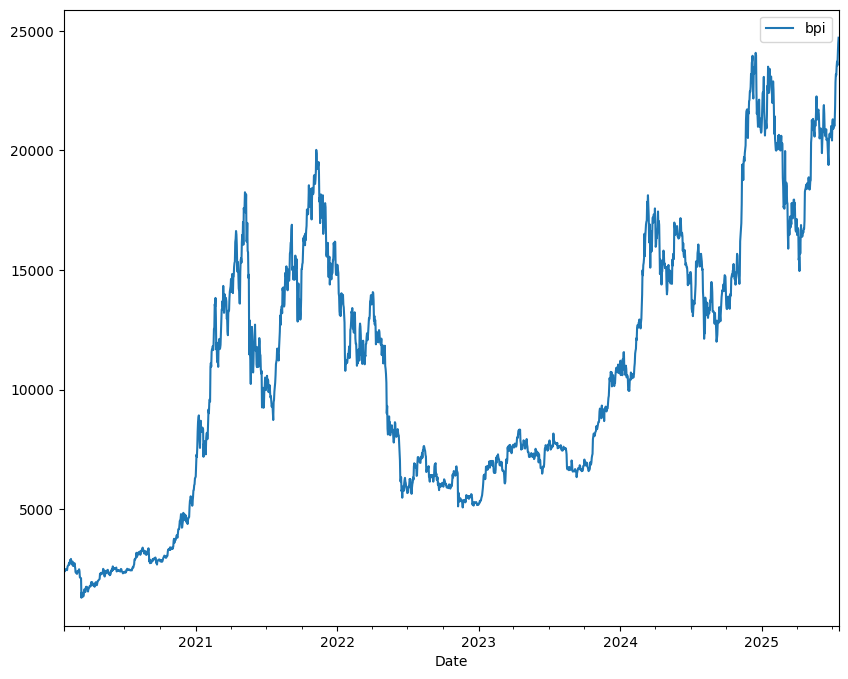

In [63]:
df.plot()

 D Calendar day
 B Business day
 W weekly  
 M monthly
 Q quarterly
 A Year end
 H Hours
 T Minutes
 S Seconds

In [64]:
df.resample('Q').mean()

,bpi
Date,
2020-03-31,2228.971970
2020-06-30,2240.112198
2020-09-30,2872.582174
2020-12-31,4077.607065
2021-03-31,10740.709333
2021-06-30,13533.053297
2021-09-30,12834.938152
2021-12-31,16951.374891
2022-03-31,12454.149889


<Axes: xlabel='Date'>

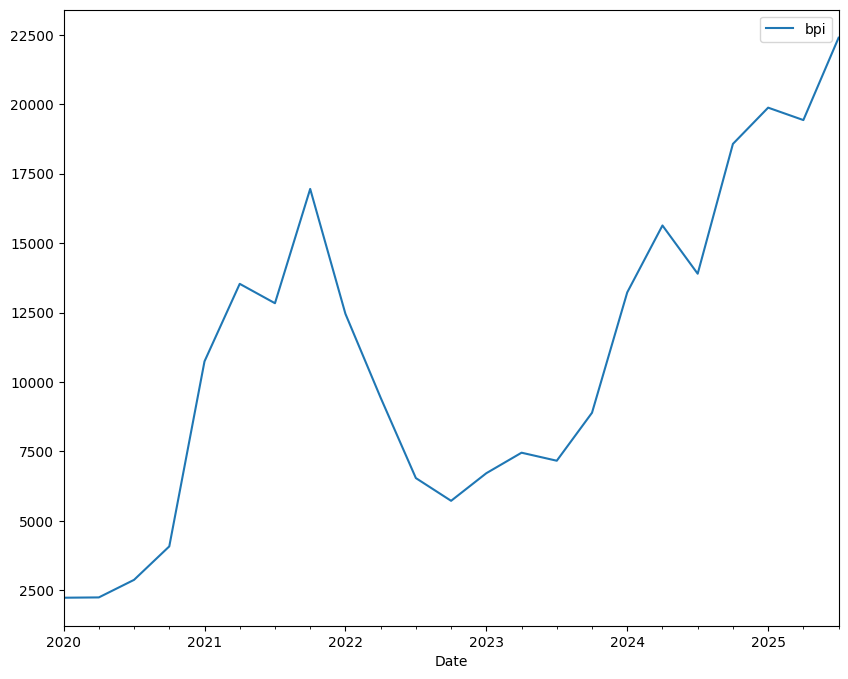

In [65]:
df.resample('Q').mean().plot()

<Axes: xlabel='Date'>

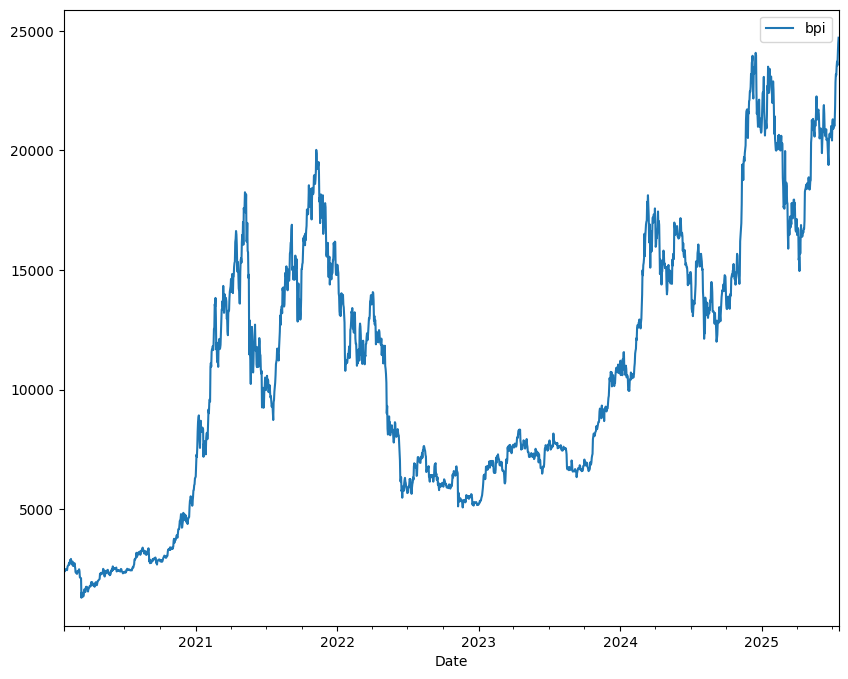

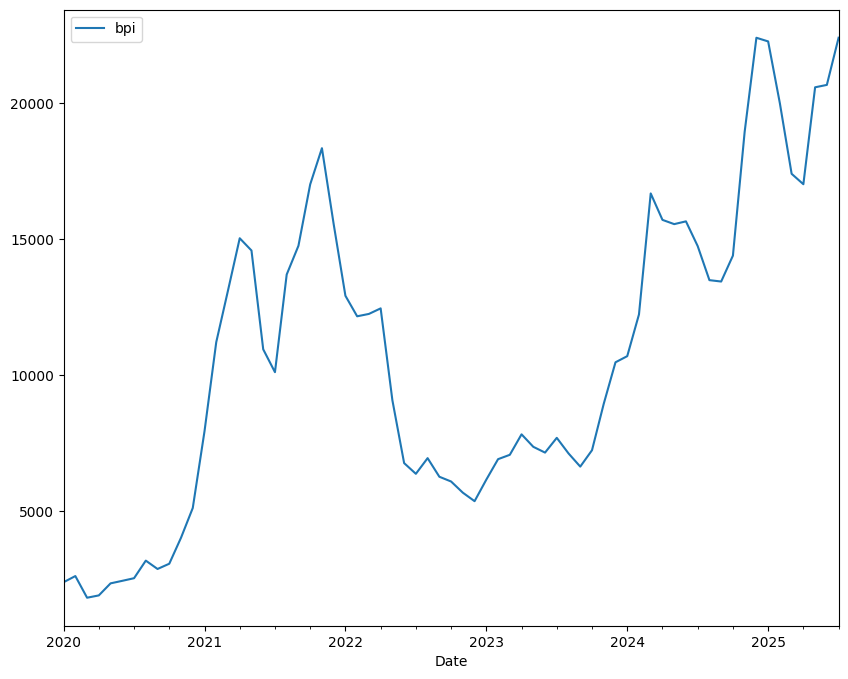

In [66]:
df.plot()
df.resample('M').mean().plot()

In [67]:
df[:5]

,bpi
Date,
2020-01-26,2260.05
2020-01-27,2331.68
2020-01-28,2439.62
2020-01-29,2419.41
2020-01-30,2492.45


In [68]:
df[:5].diff()
# data = t - (t-1)

,bpi
Date,
2020-01-26,NaN
2020-01-27,71.63
2020-01-28,107.94
2020-01-29,-20.21
2020-01-30,73.04


In [69]:
df[:5].diff(2)

,bpi
Date,
2020-01-26,NaN
2020-01-27,NaN
2020-01-28,179.57
2020-01-29,87.73
2020-01-30,52.83


<Axes: xlabel='Date'>

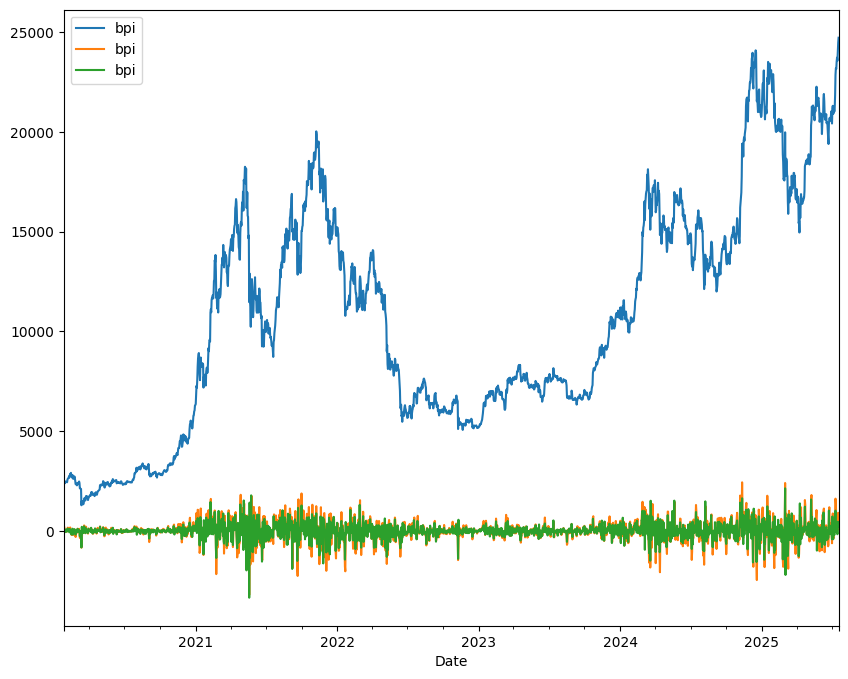

In [70]:
pd.concat([df['bpi'], df['bpi'].diff(2), df['bpi'].diff()], axis=1).plot()

In [71]:
df[:5]

,bpi
Date,
2020-01-26,2260.05
2020-01-27,2331.68
2020-01-28,2439.62
2020-01-29,2419.41
2020-01-30,2492.45


In [72]:
df[:5].shift()

,bpi
Date,
2020-01-26,NaN
2020-01-27,2260.05
2020-01-28,2331.68
2020-01-29,2439.62
2020-01-30,2419.41


In [82]:
df[:5].shift(periods=2, freq='D')

,bpi
Date,
2020-01-28,2260.05
2020-01-29,2331.68
2020-01-30,2439.62
2020-01-31,2419.41
2020-02-01,2492.45


In [74]:
df[:5] - df[:5].shift()

,bpi
Date,
2020-01-26,NaN
2020-01-27,71.63
2020-01-28,107.94
2020-01-29,-20.21
2020-01-30,73.04


<Axes: xlabel='Date'>

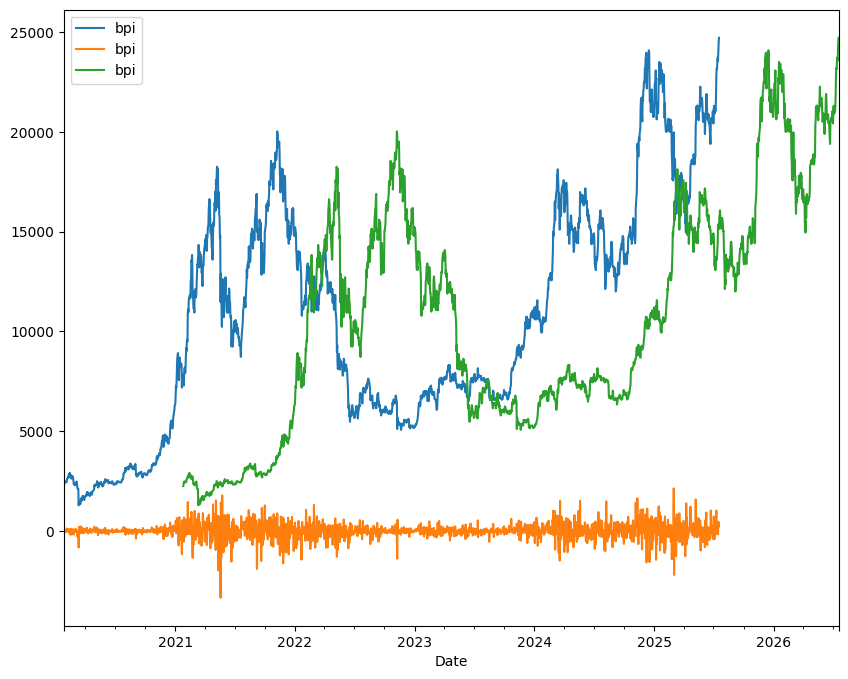

In [75]:
pd.concat([df,df-df.shift(), df.shift(periods=365, freq='D')], axis=1).plot()

<Axes: xlabel='Date'>

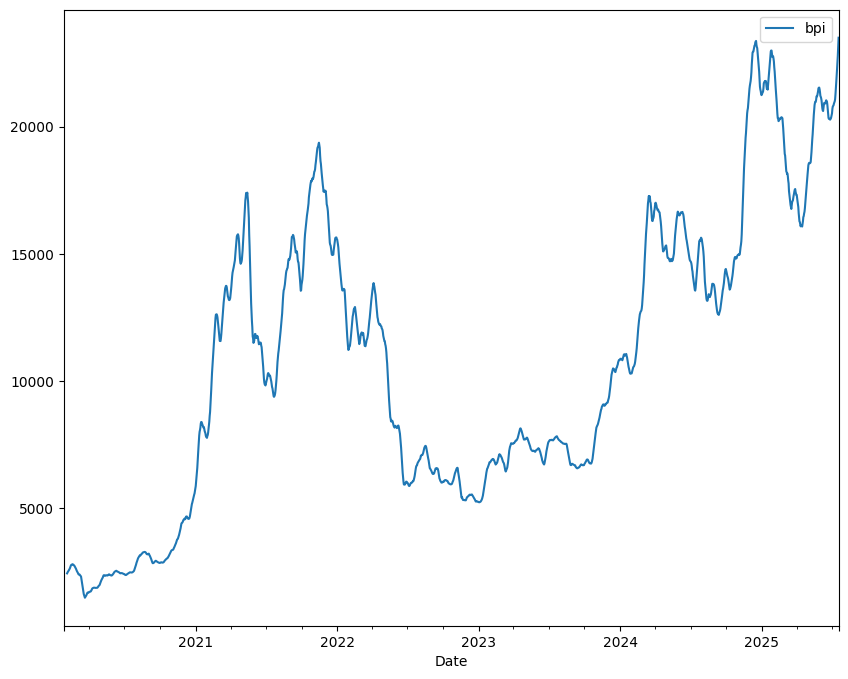

In [76]:
df.rolling(window=10).mean().plot()

<Axes: xlabel='Date'>

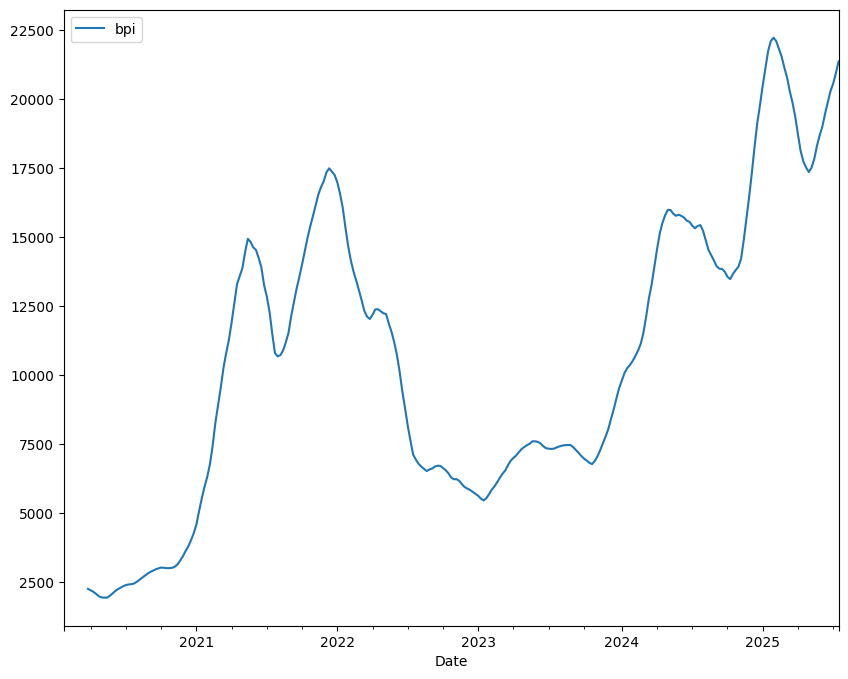

In [77]:
df.resample('W').mean().rolling(window=10).mean().plot()

<Axes: title={'center': 'Gaussian Rolling Sum (std=100)'}, xlabel='Date', ylabel='Value'>

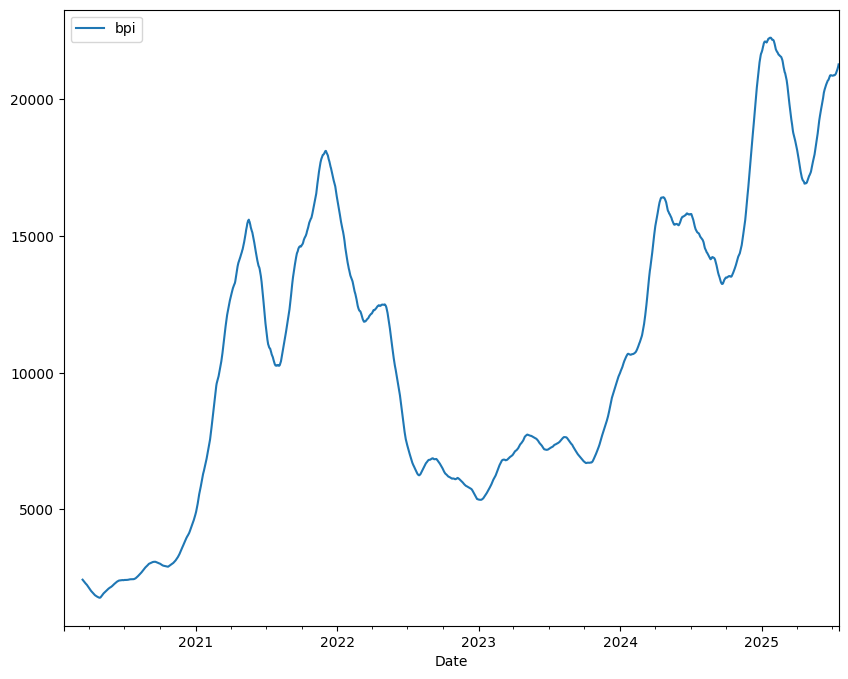

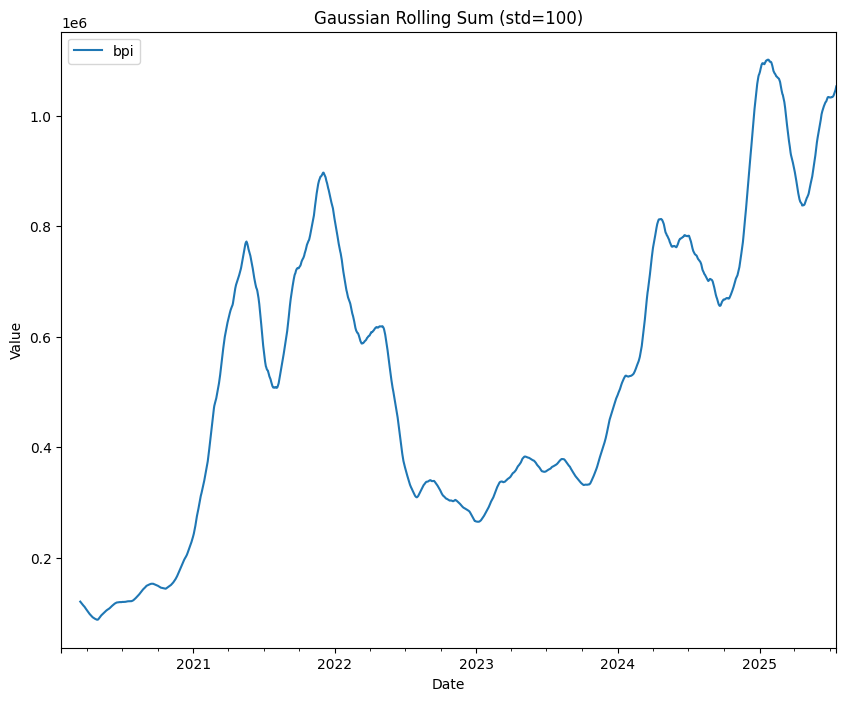

In [83]:
df.rolling(window=50).mean().plot()
df.rolling(window=50, win_type='gaussian').sum(std=100).plot(
    title='Gaussian Rolling Sum (std=100)',
    xlabel='Date',
    ylabel='Value'
)

<Axes: xlabel='Date'>

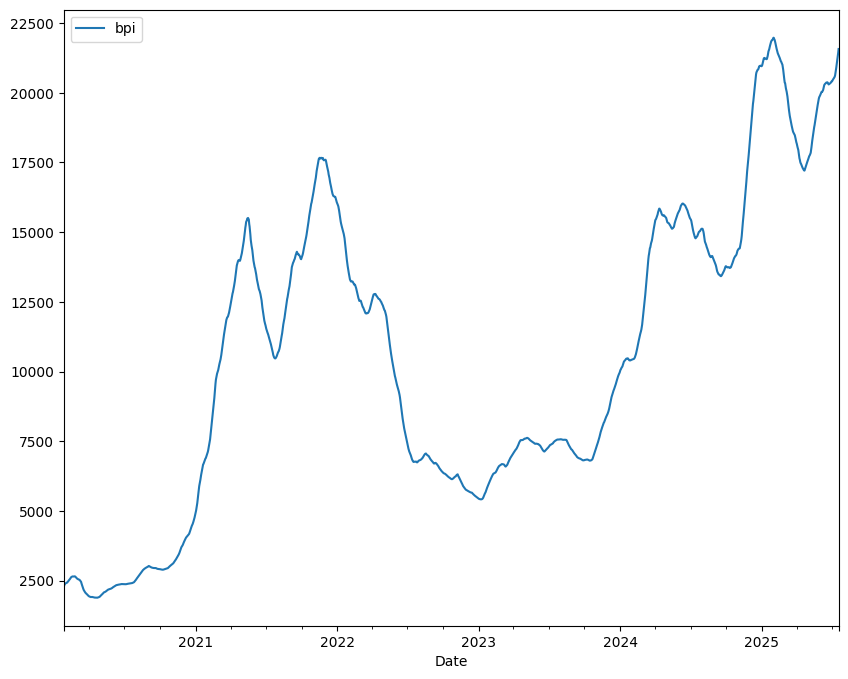

In [84]:
df.ewm(span=50).mean().plot()

<Axes: xlabel='Date'>

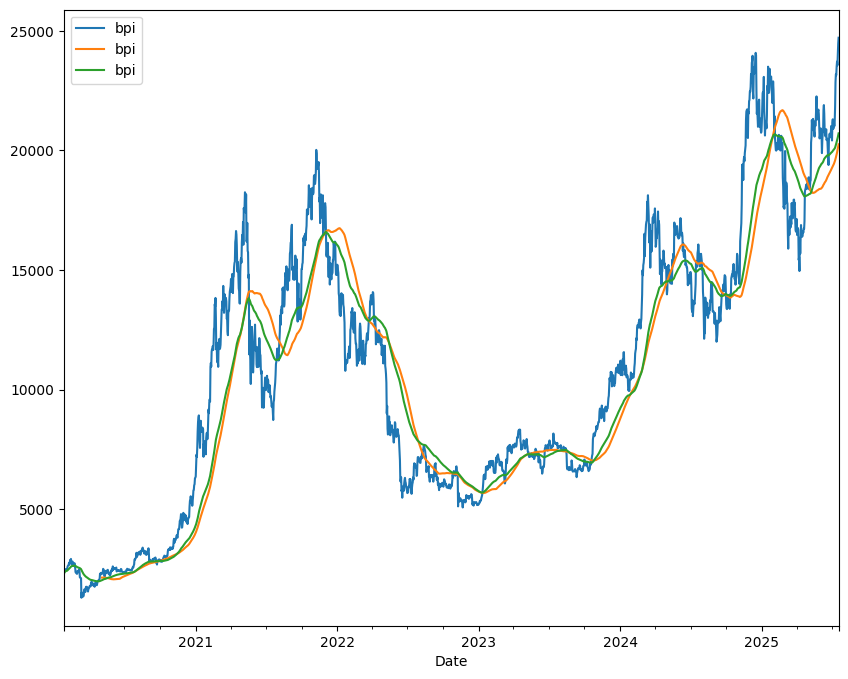

In [85]:
pd.concat([df, df.rolling(window=100).mean(),df.ewm(span=100).mean()], axis=1).plot()

PART 2


In [87]:
df.groupby(df.index.day_of_week).mean()

,bpi
Date,
0,10667.751469
1,10657.783636
2,10707.124476
3,10694.455699
4,10706.611439
5,10673.557158
6,10646.001469


In [88]:
df.groupby(df.index.month).mean()

,bpi
Date,
1,11639.563789
2,10816.014765
3,11390.596075
4,11658.377667
5,11585.799839
6,10607.698389
7,9762.983881
8,8892.796129
9,8798.888867


In [89]:
df.groupby(df.index.year).mean()

,bpi
Date,
2020,2904.339501
2021,13530.171205
2022,8511.886740
2023,7559.342767
2024,15337.347186
2025,19901.537445


In [90]:
df[:5]

,bpi
Date,
2020-01-26,2260.05
2020-01-27,2331.68
2020-01-28,2439.62
2020-01-29,2419.41
2020-01-30,2492.45


In [91]:
df[:5].cumsum()

,bpi
Date,
2020-01-26,2260.05
2020-01-27,4591.73
2020-01-28,7031.35
2020-01-29,9450.76
2020-01-30,11943.21


In [93]:
df[:5]

,bpi
Date,
2020-01-26,2260.05
2020-01-27,2331.68
2020-01-28,2439.62
2020-01-29,2419.41
2020-01-30,2492.45


In [92]:
df[:5].pct_change(2)

,bpi
Date,
2020-01-26,NaN
2020-01-27,NaN
2020-01-28,0.079454
2020-01-29,0.037625
2020-01-30,0.021655


In [94]:
df[:5].expanding().sum()

,bpi
Date,
2020-01-26,2260.05
2020-01-27,4591.73
2020-01-28,7031.35
2020-01-29,9450.76
2020-01-30,11943.21


In [95]:
df[:5].expanding().mean()

,bpi
Date,
2020-01-26,2260.050000
2020-01-27,2295.865000
2020-01-28,2343.783333
2020-01-29,2362.690000
2020-01-30,2388.642000
